# BME Lab 114 — Morphology-Elasticity Relationship of Trabecular Bone

**Author:** Simone Poncioni, MSB  
**Date:** Spring Semester 2026

---

## Notebook 1: Pre-processing

In the previous notebook, you loaded and visualised a raw µCT scan of a trabecular bone rod. Before we can run a Finite Element simulation, the raw greyscale image must be converted into a clean binary mask representing bone vs. void.

This notebook walks you through the full pre-processing pipeline:

1. Loading the raw image
2. Smoothing (Gaussian filter)
3. Segmentation (Otsu thresholding)
4. Cropping to the region of interest
5. Morphological cleaning
6. Saving the final segmentation

### 0. Imports

In [1]:
%matplotlib inline

import sys
from pathlib import Path
import numpy as np

parent_dir = Path.cwd().parent
sys.path.insert(0, str(parent_dir))

from utils.img_io import read_image, write_image
from utils.viewer_utils import display_image_cursor, visualize_otsu_hist
from core.segmentation import otsu_threshold_itk_with_threshold, gaussian_smoothing_itk, crop_bbox, morph_cleaning

### 1. Load Image

We begin by loading the raw `.ISQ` file from the µCT scanner. The image is read both as an ITK object (needed for filter operations) and as a NumPy array (needed for visualisation and numerical operations).

In [2]:
# imgpath = Path("../../00_DATA/00_test/Sample1.ISQ")
imgpath = Path("../../00_DATA/group01/A1/C0004351.ISQ")
outpath = imgpath.parent / "derived"
outpath.mkdir(exist_ok=True, parents=True)

img_itk, img_np = read_image(imgpath)

### 2. Visualise the Raw Image

Use the interactive viewer to inspect the image. Notice the grayscale intensity distribution — bone tissue appears bright, while the marrow space and background are dark.

In [3]:
display_image_cursor(img_np, "Original Image")

interactive(children=(IntSlider(value=350, description='Slice:', max=699), Output()), _dom_classes=('widget-in…

### 3. Smoothing and Segmentation

Raw µCT images contain noise that can corrupt the segmentation. We first apply a **Gaussian filter** to smooth the image, then use **Otsu's method** to automatically find the optimal intensity threshold separating bone from background.

> **Task:** Inspect the histogram plot below. Does the threshold look reasonable? What happens if the image is *not* smoothed before thresholding?

In [4]:
# sigma: 1 * voxel spacing (extract from itk image metadata)
seg_smooth = gaussian_smoothing_itk(img_itk)

seg_smooth_np = np.array(seg_smooth)
display_image_cursor(seg_smooth_np, "Smoothed Image")

seg_otsu, threshold = otsu_threshold_itk_with_threshold(seg_smooth)
display_image_cursor(seg_otsu, "Otsu Thresholding Segmentation")

interactive(children=(IntSlider(value=350, description='Slice:', max=699), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=350, description='Slice:', max=699), Output()), _dom_classes=('widget-in…

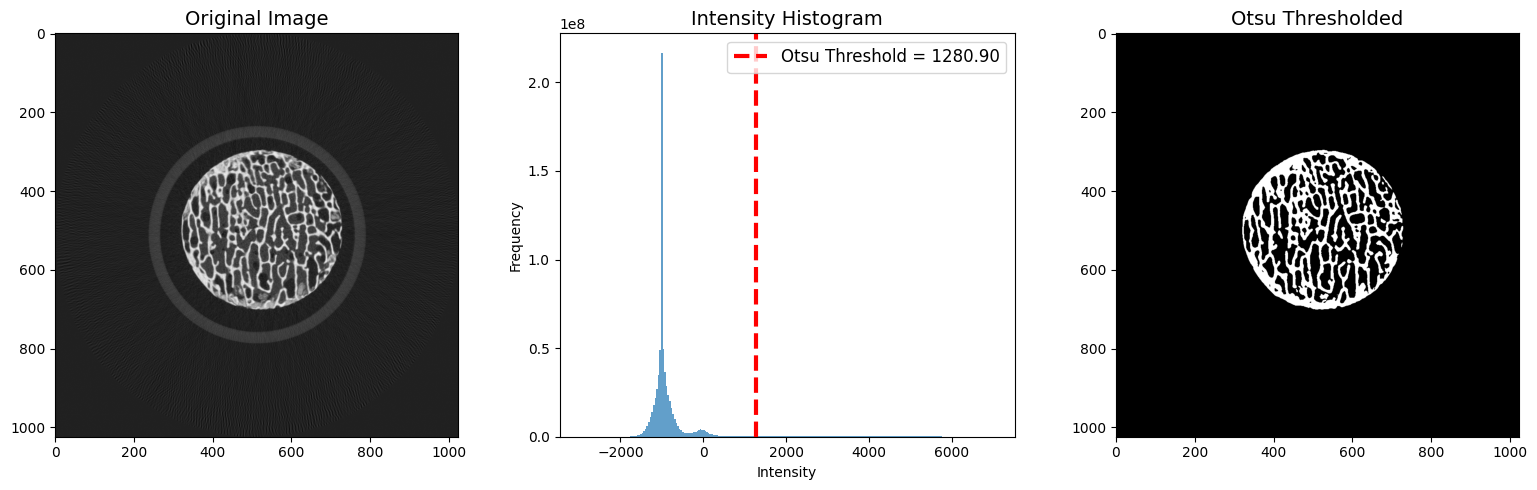

Otsu's threshold value: 1280.8975
Pixels above threshold: 33,312,354 (4.54%)
Pixels below threshold: 700,690,846 (95.46%)


In [5]:
visualize_otsu_hist(img_np, seg_otsu, threshold)

In [6]:
# crop image to minimum bounding box around segmented region + 20 voxels margin
print(np.shape(seg_otsu))
cropped_seg_otsu, bbox = crop_bbox(seg_otsu, padding=10)
print(np.shape(cropped_seg_otsu))

print(540 * img_itk.GetSpacing()[0])

(700, 1024, 1024)
(635, 453, 477)
18.57568359375


In [7]:
display_image_cursor(cropped_seg_otsu, "Smoothed Image")


interactive(children=(IntSlider(value=317, description='Slice:', max=634), Output()), _dom_classes=('widget-in…

### 4. Morphological Cleaning

Otsu thresholding often produces small spurious islands of misclassified voxels. We apply a **morphological closing** to fill small holes within the bone, then retain only the **largest connected component** to remove isolated noise clusters.

In [8]:
# Morphological close of binary image
morph_diam = 3  # voxels
final_seg = morph_cleaning(cropped_seg_otsu, morph_diam)

### 5. Save Segmentation

The cleaned binary mask is saved in `.mha` and `.npy` formats for use in the next notebook (mesh generation).

In [9]:
write_path = outpath / f"{imgpath.stem}_segmented.mha"
write_image(final_seg, write_path)
write_image(final_seg, write_path.with_suffix(".npy"))